# Paper Reporting Artifacts

This notebook builds the paper-facing tables and figures for the ICDM, CIKM, and ECML variants without touching the model training scripts or the existing experiment notebooks.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

WORKSPACE_ROOT = Path.cwd()
if not (WORKSPACE_ROOT / 'evaluation').exists():
    WORKSPACE_ROOT = WORKSPACE_ROOT.parent
if not (WORKSPACE_ROOT / 'evaluation').exists():
    raise FileNotFoundError('Could not resolve workspace root from the notebook working directory.')
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

from evaluation.paper_assets import PaperPaths, generate_paper_assets

PLAN_NAME = 'complete_20seed_20260426'
OUTPUT_ROOT = WORKSPACE_ROOT / 'outputs' / 'paper_assets' / PLAN_NAME
BOOTSTRAP_RESAMPLES = 2000
GENERATE_FIGURES = True

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)

OUTPUT_ROOT

WindowsPath('c:/DevSpace/PyDevspace/CMDL/outputs/paper_assets/complete_20seed_20260426')

In [2]:
artifacts = generate_paper_assets(
    paths=PaperPaths(workspace_root=WORKSPACE_ROOT, plan_name=PLAN_NAME),
    output_root=OUTPUT_ROOT,
    include_figures=GENERATE_FIGURES,
    n_boot=BOOTSTRAP_RESAMPLES,
    bootstrap_seed=0,
)

manifest = json.loads(artifacts.manifest_path.read_text(encoding='utf-8'))
display(Markdown('## Manifest'))
display(pd.Series({
    'manifest_path': str(artifacts.manifest_path),
    'table_count': len(manifest['tables']),
    'figure_count': len(manifest['figures']),
}))

## Manifest

manifest_path    c:\DevSpace\PyDevspace\CMDL\outputs\paper_asse...
table_count                                                     13
figure_count                                                     9
dtype: object

In [3]:
TABLE_PREVIEW_ORDER = [
    'verdict_matrix.csv',
    'synthetic_main_table.csv',
    'synthetic_bootstrap_ci.csv',
    'realdata_forecast_table.csv',
    'ablation_degeneracy_table.csv',
    'proxy_metadata_table.csv',
]

for table_name in TABLE_PREVIEW_ORDER:
    table_path = Path(manifest['tables'][table_name])
    display(Markdown(f'## {table_name}'))
    display(pd.read_csv(table_path).head(20))

## verdict_matrix.csv

,domain,layer,verdict,evidence
0,synthetic,L0_forecast,certified,CMDL beats Plain LSTM on task loss in both lin...
1,synthetic,L2_structured_mechanism,certified,CMDL beats Plain LSTM on k* MAE and ablation c...
2,synthetic,L3_directional_alignment,certified,CMDL keeps positive-seed share high and rank a...
3,economics,L0_forecast,not_certified,CMDL mean test_r2=0.05414579722609828; best co...
4,economics,L2_structured_mechanism,certified,CMDL stratified rows remain valid while No AC ...
5,economics,L3_directional_alignment,mixed,"anchor_adjusted_rho_mean=-0.10869306317884078,..."
6,energy,L0_forecast,not_certified,CMDL mean test_r2=-0.028567153527486667; best ...
7,energy,L2_structured_mechanism,certified,CMDL stratified rows remain valid while No AC ...
8,energy,L3_directional_alignment,mixed,anchor_adjusted_rho_mean=-0.014338563591048481...


## synthetic_main_table.csv

,display_name,family,variant,scenario,task_loss_mean,task_loss_std,effective_kstar_mae_mean,effective_kstar_mae_std,effective_kstar_spearman_rho_mean,effective_kstar_spearman_rho_std,effective_lag_entropy_mean_mean,effective_lag_entropy_mean_std,effective_lag_peak_accuracy_mean,effective_lag_peak_accuracy_std,proxy_signal_r2_mean,proxy_signal_r2_std,z_signal_spearman_rho_mean,z_signal_spearman_rho_std,n_seeds,kstar_positive_seed_share
0,CMDL,cmdl,NaN,linear,0.036238,0.004377,1.159093,0.226536,0.944896,0.078103,1.905189,8.507169e-02,0.34675,0.072171,8.995846e-01,9.044959e-02,0.954648,0.080977,20,1.0
1,No AC Encoder,ablation,no_ac_encoder,linear,0.062946,0.005430,1.931170,0.162463,0.000000,0.000000,2.001045,7.139045e-02,0.13900,0.030245,-1.476138e+16,4.750151e+16,0.000000,0.000000,20,0.0
2,No Recon Regularization,ablation,no_recon_regularization,linear,0.036329,0.004310,1.159246,0.226639,0.944675,0.078489,1.904514,8.510755e-02,0.34700,0.072555,8.993343e-01,9.071034e-02,0.954408,0.081383,20,1.0
3,Plain LSTM,plain_lstm,NaN,linear,0.069503,0.002897,1.706720,0.090700,0.356054,0.065714,2.148185,1.923208e-02,0.12875,0.018699,NaN,NaN,NaN,NaN,20,1.0
4,Uniform Lag,ablation,uniform_lag,linear,0.069512,0.002694,1.912750,0.087577,0.000000,0.000000,2.302585,4.556259e-16,0.00000,0.000000,8.483472e-01,1.571878e-01,0.945730,0.091668,20,0.0
5,CMDL,cmdl,NaN,nonlinear,0.037825,0.006533,1.466921,0.248345,0.906988,0.212393,1.833295,8.275586e-02,0.48800,0.041403,8.886551e-01,1.987195e-01,0.945222,0.204769,20,1.0
6,No AC Encoder,ablation,no_ac_encoder,nonlinear,0.066058,0.018424,2.435219,0.260711,0.000000,0.000000,1.820658,1.139148e-01,0.27675,0.150493,-2.850363e+16,5.384774e+16,0.000000,0.000000,20,0.0
7,No Recon Regularization,ablation,no_recon_regularization,nonlinear,0.037843,0.006660,1.466841,0.248370,0.908675,0.204805,1.833409,8.269997e-02,0.48850,0.041330,8.898297e-01,1.934375e-01,0.943500,0.212479,20,1.0
8,Plain LSTM,plain_lstm,NaN,nonlinear,0.092684,0.006085,2.610799,0.137687,0.343930,0.092467,2.089441,2.812506e-02,0.22725,0.023923,NaN,NaN,NaN,NaN,20,1.0
9,Uniform Lag,ablation,uniform_lag,nonlinear,0.093817,0.008114,3.101750,0.097809,0.000000,0.000000,2.302585,4.556259e-16,0.39300,0.027549,8.270833e-01,2.264659e-01,0.911128,0.180868,20,0.0


## synthetic_bootstrap_ci.csv

...

,domain,display_name,family,variant,target_column,feature_bundle,n_seeds,test_r2_mean,test_r2_std,anchor_adjusted_rho_mean,anchor_positive_seed_share,mean_proxy_adjusted_rho_mean,mean_proxy_positive_seed_share,kstar_std_mean,entropy_mean,lag_gate_sensitivity_range_mean,proxy_signal_r2_mean
0,economics,CMDL,cmdl,NaN,ctfp,effective_labor_aware,20,0.054146,3.732276e-02,-0.108693,0.35,-0.038753,0.45,0.167289,1.852977,0.499122,0.305193
1,economics,Grouped ARDL,grouped_ardl,NaN,ctfp,effective_labor_aware,20,-0.089107,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,economics,No AC Encoder,ablation,no_ac_encoder,ctfp,effective_labor_aware,20,0.051821,3.536224e-02,NaN,NaN,NaN,NaN,0.000000,1.839098,0.000000,NaN
3,economics,No Recon Regularization,ablation,no_recon_regularization,ctfp,effective_labor_aware,20,0.055259,3.293678e-02,0.163773,0.60,0.311643,0.70,0.109203,1.844385,0.338775,0.220789
4,economics,Plain LSTM,plain_lstm,NaN,ctfp,effective_labor_aware,20,0.102420,2.135252e-02,-0.017295,0.25,-0.117040,0.05,1.894237,1.872628,NaN,NaN
5,economics,Uniform Lag,ablation,uniform_lag,ctfp,effective_labor_aware,20,0.103965,2.800837e-02,NaN,NaN,NaN,NaN,0.000000,2.302585,0.734900,0.334655
6,energy,CMDL,cmdl,NaN,co2_per_unit_energy,minimal,20,-0.028567,5.017912e-03,-0.014339,0.50,-0.012376,0.45,0.107912,1.857062,0.269047,0.673696
7,energy,Grouped ARDL,grouped_ardl,NaN,co2_per_unit_energy,minimal,20,0.607078,1.139065e-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,energy,No AC Encoder,ablation,no_ac_encoder,co2_per_unit_energy,minimal,20,-0.028401,4.633887e-03,NaN,NaN,NaN,NaN,0.000000,1.844964,0.000000,NaN
9,energy,No Recon Regularization,ablation,no_recon_regularization,co2_per_unit_energy,minimal,20,-0.028566,5.017600e-03,-0.014375,0.50,-0.012406,0.45,0.107911,1.857061,0.269043,0.673699


## ablation_degeneracy_table.csv

,domain,method,kstar_std_mean,lag_gate_sensitivity_range_mean,anchor_adjusted_rho_mean,valid_stratifiers,degenerate_control
0,economics,CMDL,0.167289,0.499122,-0.108693,3,False
1,economics,No AC Encoder,0.000000,0.000000,NaN,0,True
2,economics,No Recon Regularization,0.109203,0.338775,0.163773,0,False
3,economics,Plain LSTM,1.894237,NaN,-0.017295,0,False
4,economics,Uniform Lag,0.000000,0.734900,NaN,0,True
5,energy,CMDL,0.107912,0.269047,-0.014339,3,False
6,energy,No AC Encoder,0.000000,0.000000,NaN,0,True
7,energy,No Recon Regularization,0.107911,0.269043,-0.014375,0,False
8,energy,Plain LSTM,1.331277,NaN,0.092539,0,False
9,energy,Uniform Lag,0.000000,0.393650,NaN,0,True


## proxy_metadata_table.csv

,domain,target_column,feature_bundle,proxy_name,proxy_role,expected_sign,source_hint,caveat_template
0,economics,ctfp,effective_labor_aware,proxy_effective_labor_anchor,anchor,-1.0,fill_from_domain_writeup,fill_from_domain_writeup
1,economics,ctfp,effective_labor_aware,proxy_mean,aggregate,NaN,fill_from_domain_writeup,fill_from_domain_writeup
2,economics,ctfp,effective_labor_aware,proxy_employment_level,auxiliary,-1.0,fill_from_domain_writeup,fill_from_domain_writeup
3,economics,ctfp,effective_labor_aware,proxy_hc_level,auxiliary,-1.0,fill_from_domain_writeup,fill_from_domain_writeup
4,economics,ctfp,effective_labor_aware,proxy_hc_trend,auxiliary,-1.0,fill_from_domain_writeup,fill_from_domain_writeup
5,energy,co2_per_unit_energy,minimal,proxy_government_effectiveness,anchor,-1.0,fill_from_domain_writeup,fill_from_domain_writeup
6,energy,co2_per_unit_energy,minimal,mean_wgi_proxy,aggregate,NaN,fill_from_domain_writeup,fill_from_domain_writeup
7,energy,co2_per_unit_energy,minimal,proxy_regulatory_quality,auxiliary,-1.0,fill_from_domain_writeup,fill_from_domain_writeup
8,energy,co2_per_unit_energy,minimal,proxy_rule_of_law,auxiliary,-1.0,fill_from_domain_writeup,fill_from_domain_writeup


In [4]:
CASE_STUDY_TABLES = [
    'economics_case_study_source.csv',
    'energy_case_study_source.csv',
]

for table_name in CASE_STUDY_TABLES:
    table_path = Path(manifest['tables'][table_name])
    display(Markdown(f'## {table_name}'))
    display(pd.read_csv(table_path).head(15))

## economics_case_study_source.csv

,domain,seed,stratifier,entity_code,entity_name,k_star,stratifier_value
0,economics,5,hc_mean_train,BFA,Burkina Faso,4.326804,1.067280
1,economics,5,hc_mean_train,NER,Niger,4.325489,1.092137
2,economics,5,hc_mean_train,MOZ,Mozambique,4.351017,1.132163
3,economics,5,hc_mean_train,AGO,Angola,4.254803,1.226918
4,economics,5,hc_mean_train,SEN,Senegal,4.297541,1.262914
5,economics,5,hc_mean_train,SDN,Sudan,4.247615,1.319140
6,economics,5,hc_mean_train,RWA,Rwanda,4.307612,1.341822
7,economics,5,hc_mean_train,CIV,Côte d'Ivoire,4.256135,1.344910
8,economics,5,hc_mean_train,NGA,Nigeria,4.225555,1.400640
9,economics,5,hc_mean_train,TZA,U.R. of Tanzania: Mainland,4.259383,1.427008


## energy_case_study_source.csv

,domain,seed,stratifier,entity_code,entity_name,k_star,stratifier_value
0,energy,3,rule_of_law_train,IRQ,Iraq,5.192461,-1.625097
1,energy,3,rule_of_law_train,VEN,Venezuela,5.192303,-1.358781
2,energy,3,rule_of_law_train,TKM,Turkmenistan,5.192441,-1.347545
3,energy,3,rule_of_law_train,UZB,Uzbekistan,5.192461,-1.243217
4,energy,3,rule_of_law_train,IRN,Iran,5.192384,-1.012539
5,energy,3,rule_of_law_train,BGD,Bangladesh,5.192339,-0.949671
6,energy,3,rule_of_law_train,KAZ,Kazakhstan,5.192229,-0.939907
7,energy,3,rule_of_law_train,BLR,Belarus,5.192460,-0.917803
8,energy,3,rule_of_law_train,RUS,Russia,5.191978,-0.913515
9,energy,3,rule_of_law_train,PAK,Pakistan,5.192099,-0.896275


## workflow_overview.png

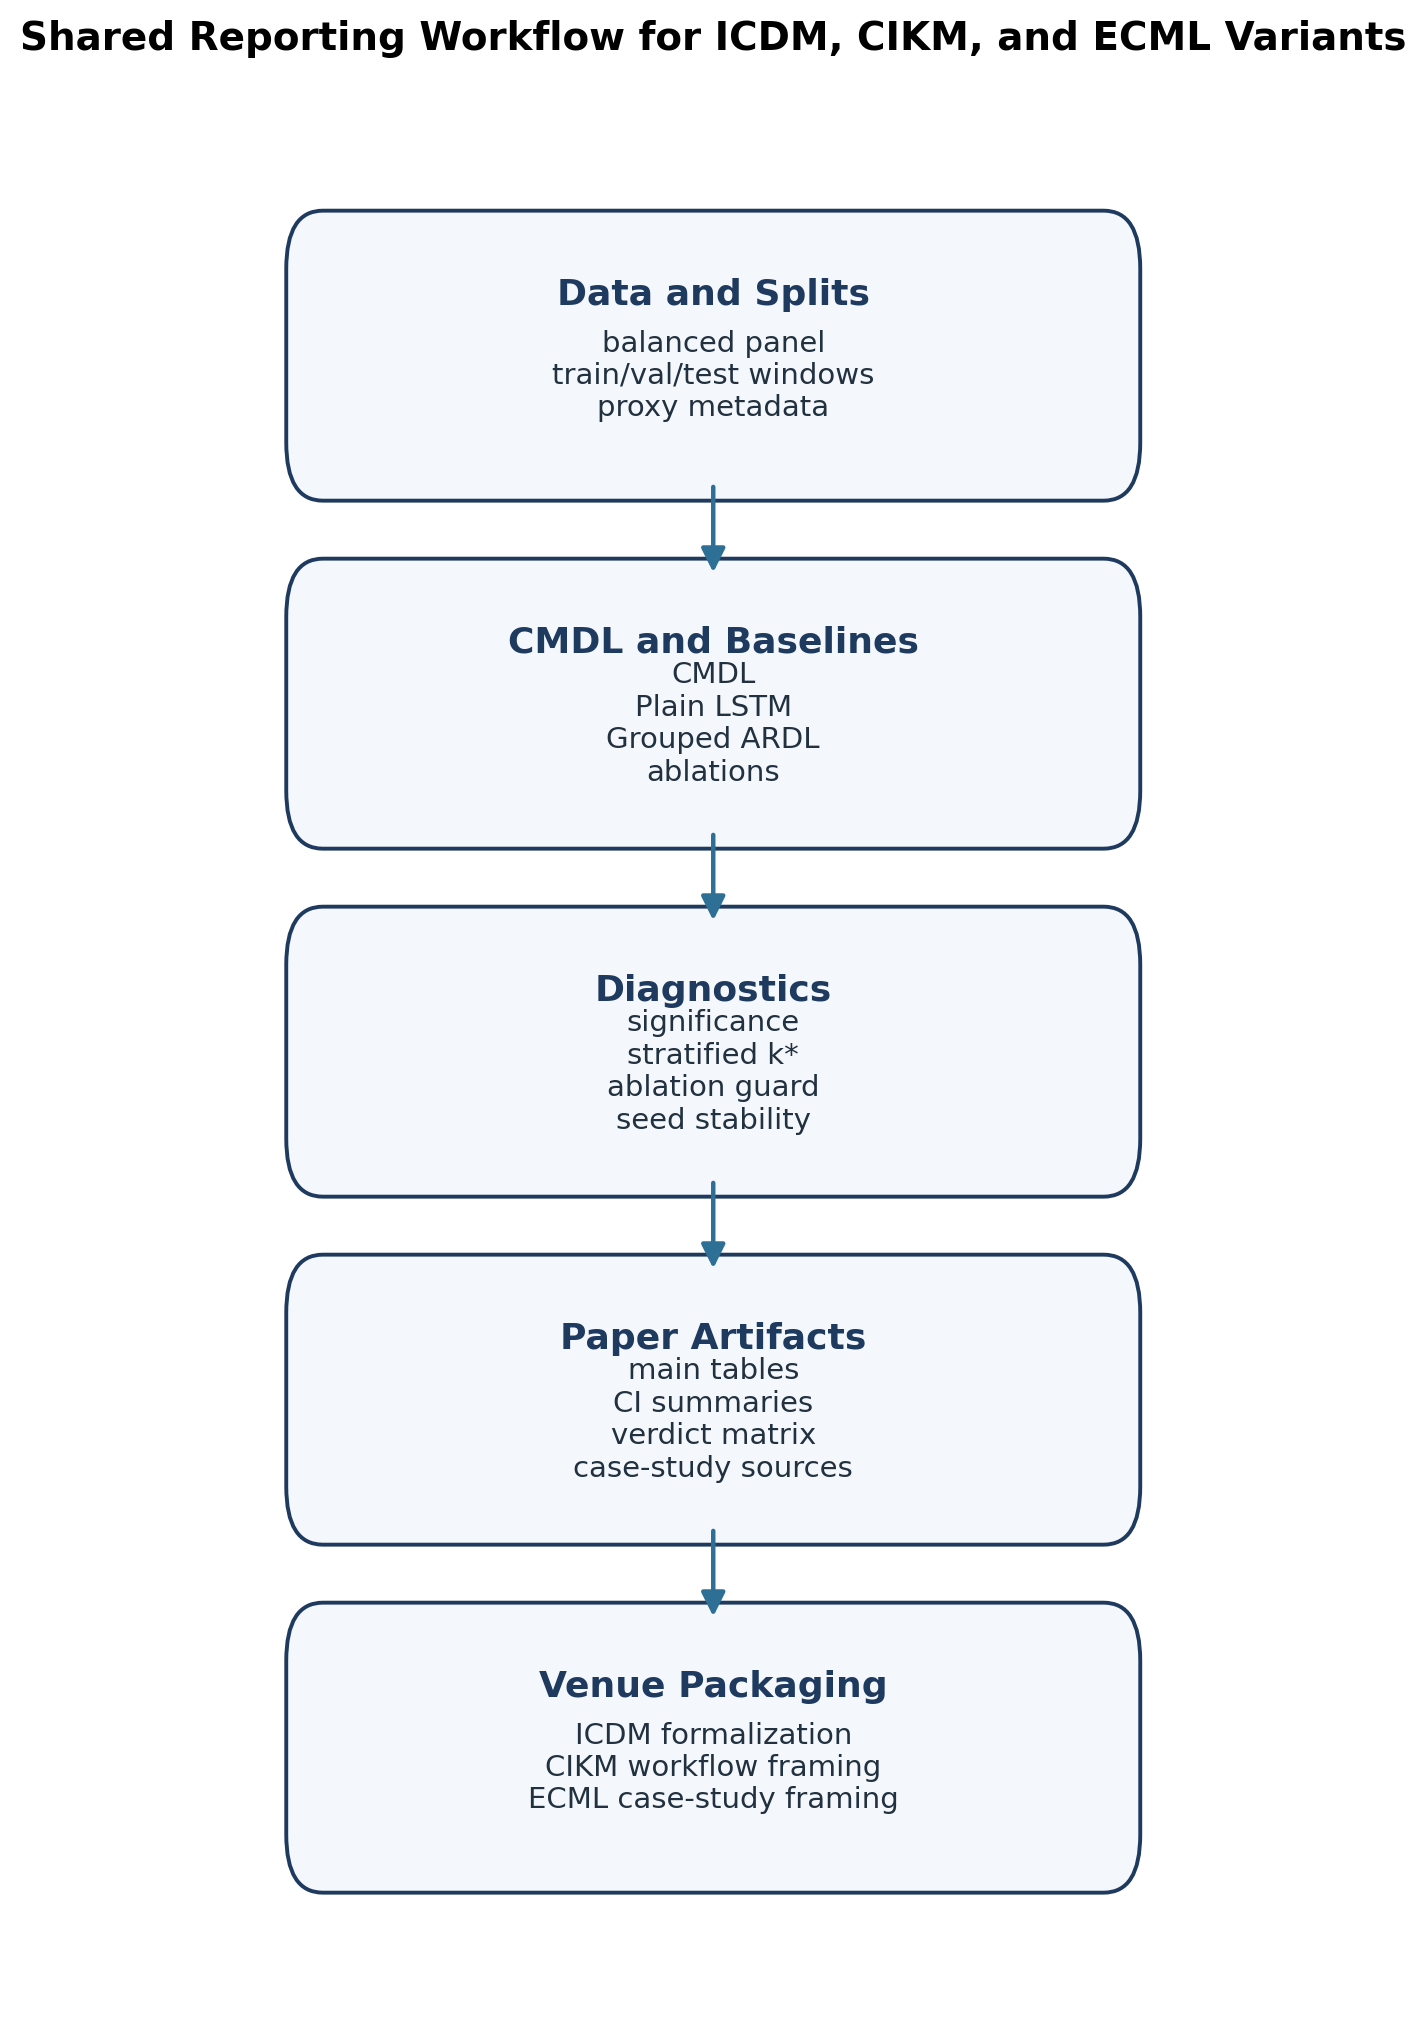

## synthetic_kstar_mae_seed_distribution_linear.png

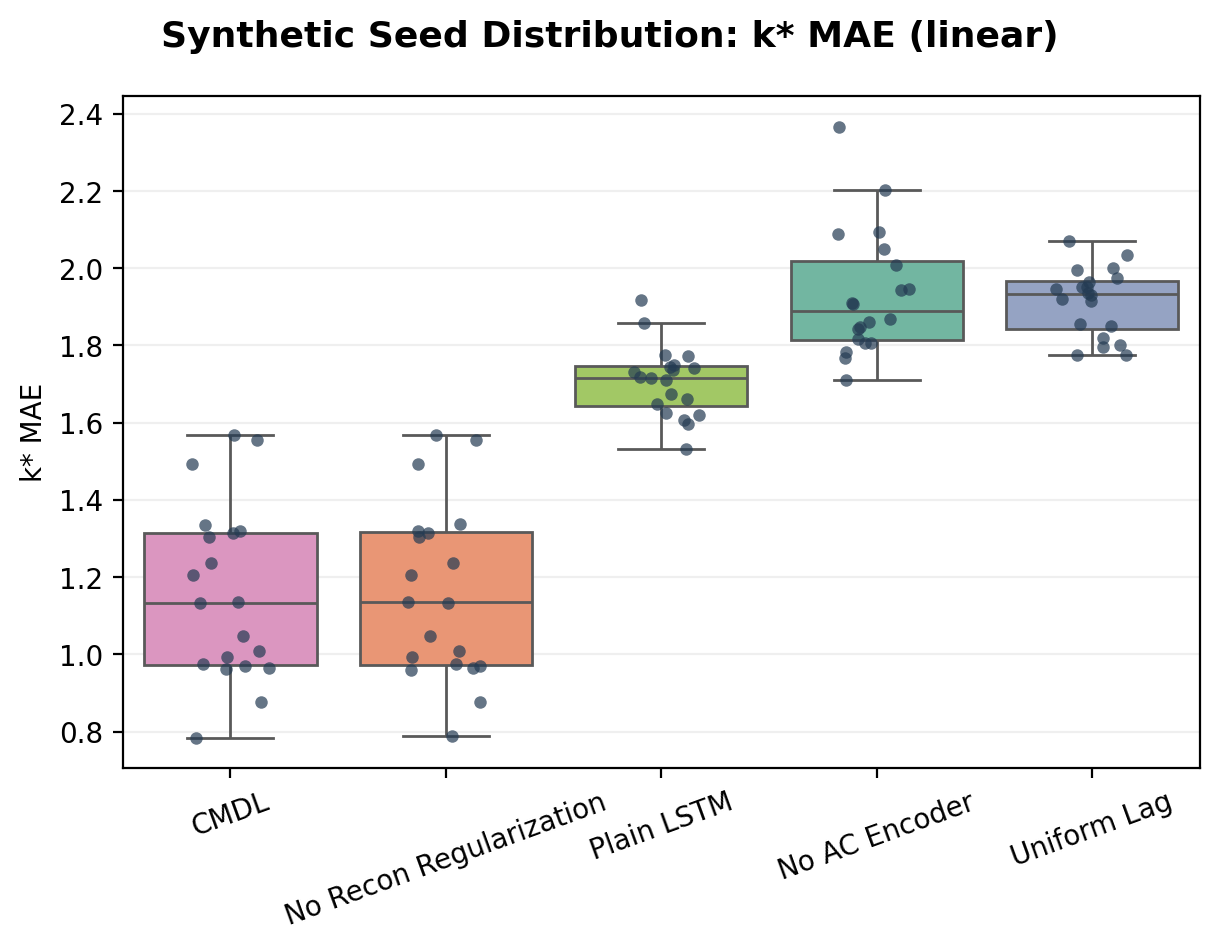

## synthetic_kstar_mae_seed_distribution_nonlinear.png

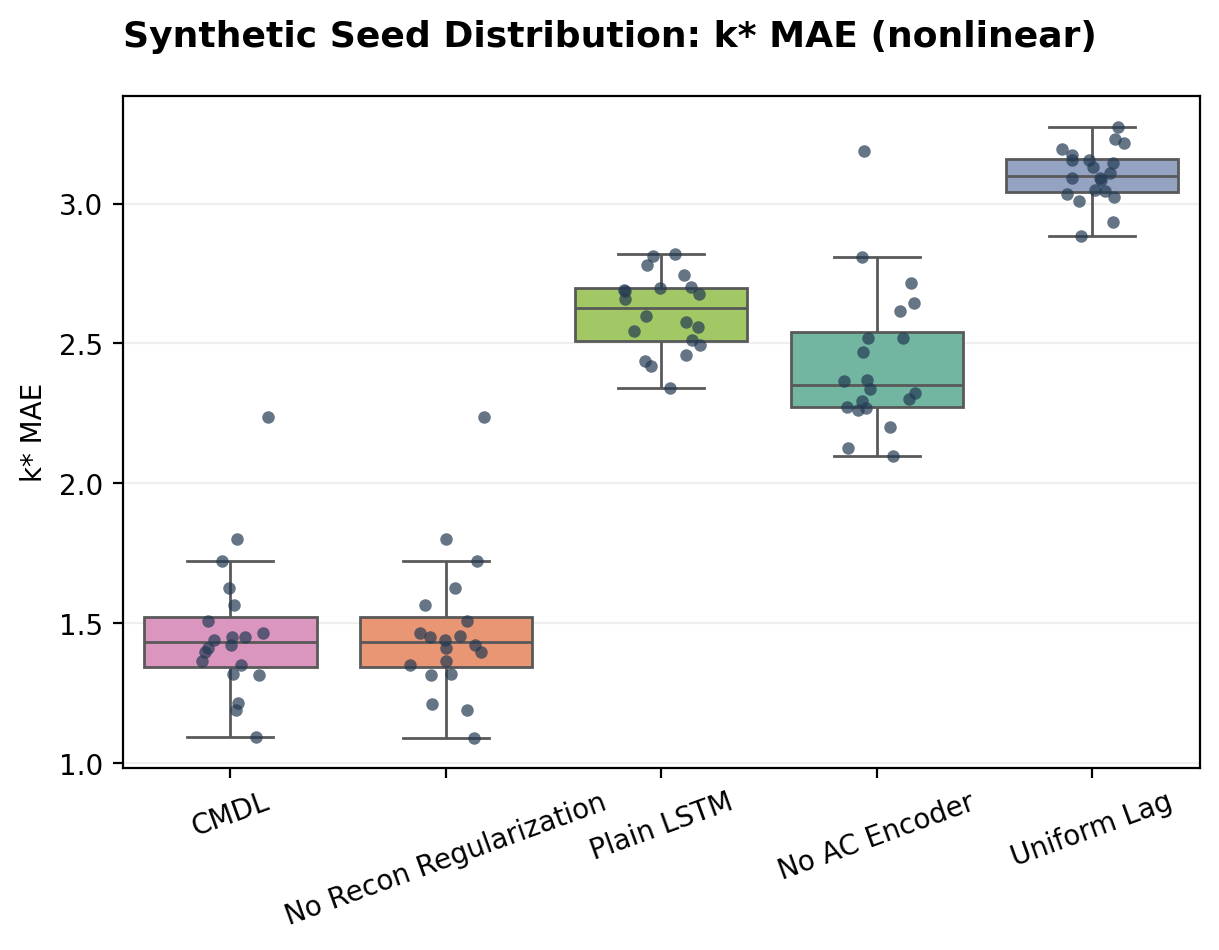

## economics_forecast_seed_distribution.png

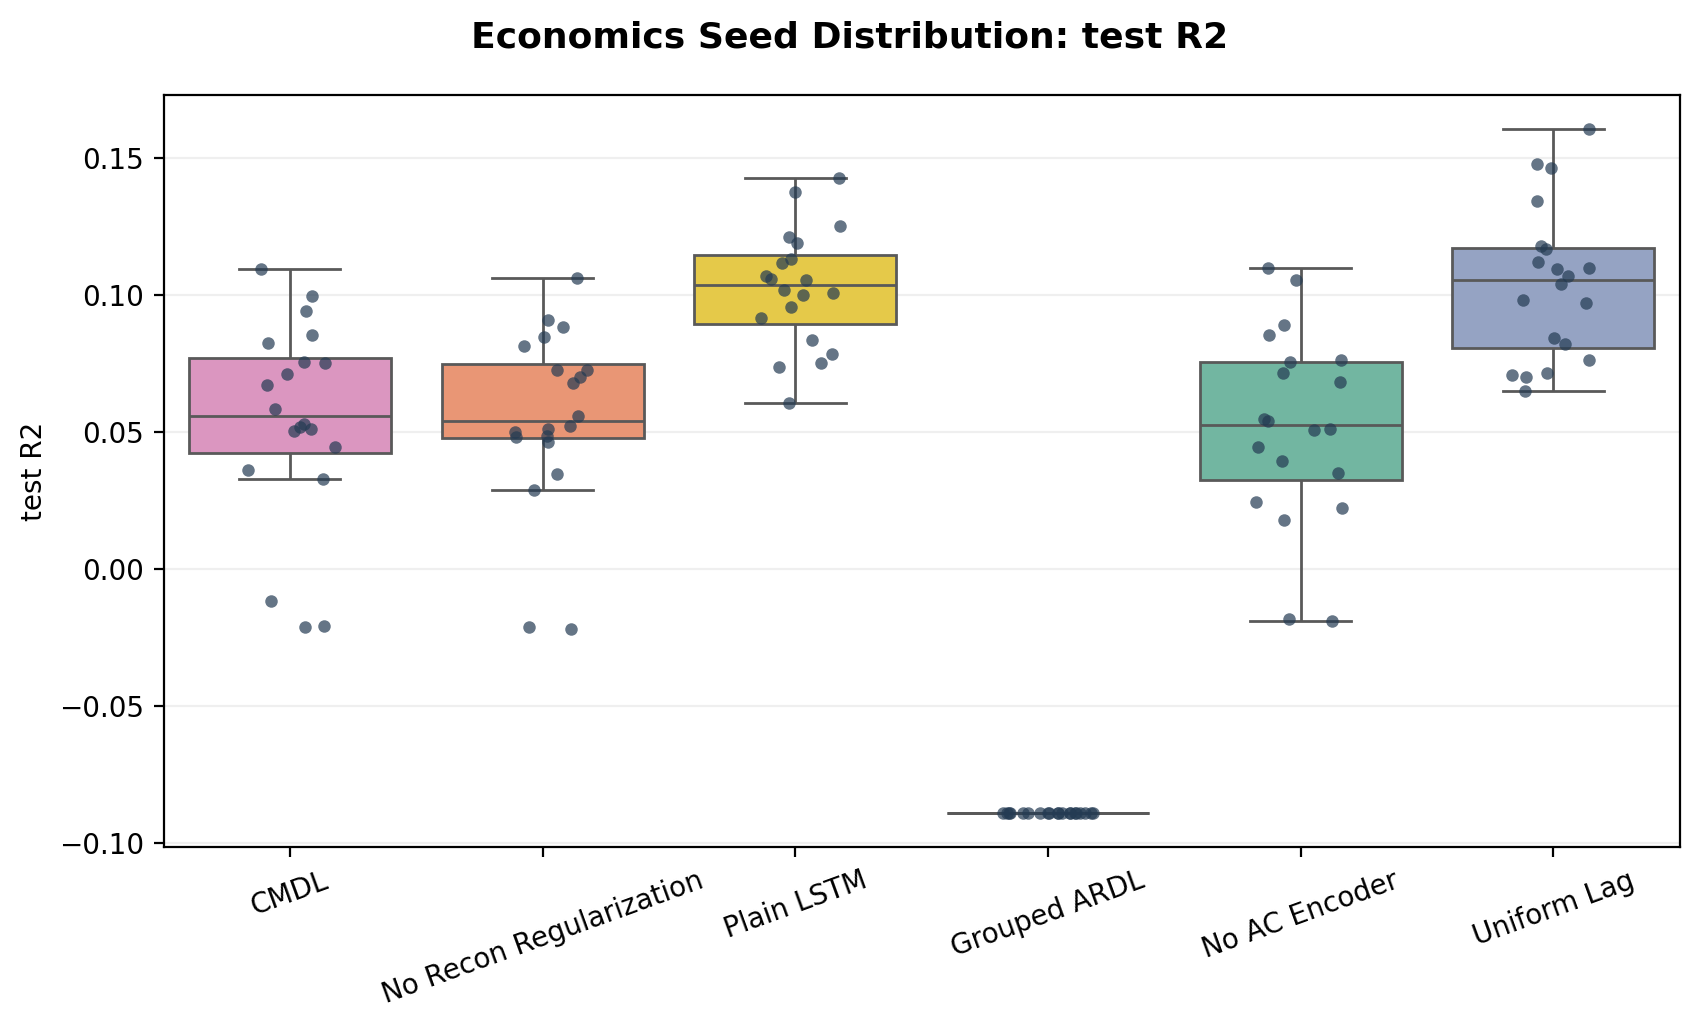

## economics_structured_mechanism_seed_distribution.png

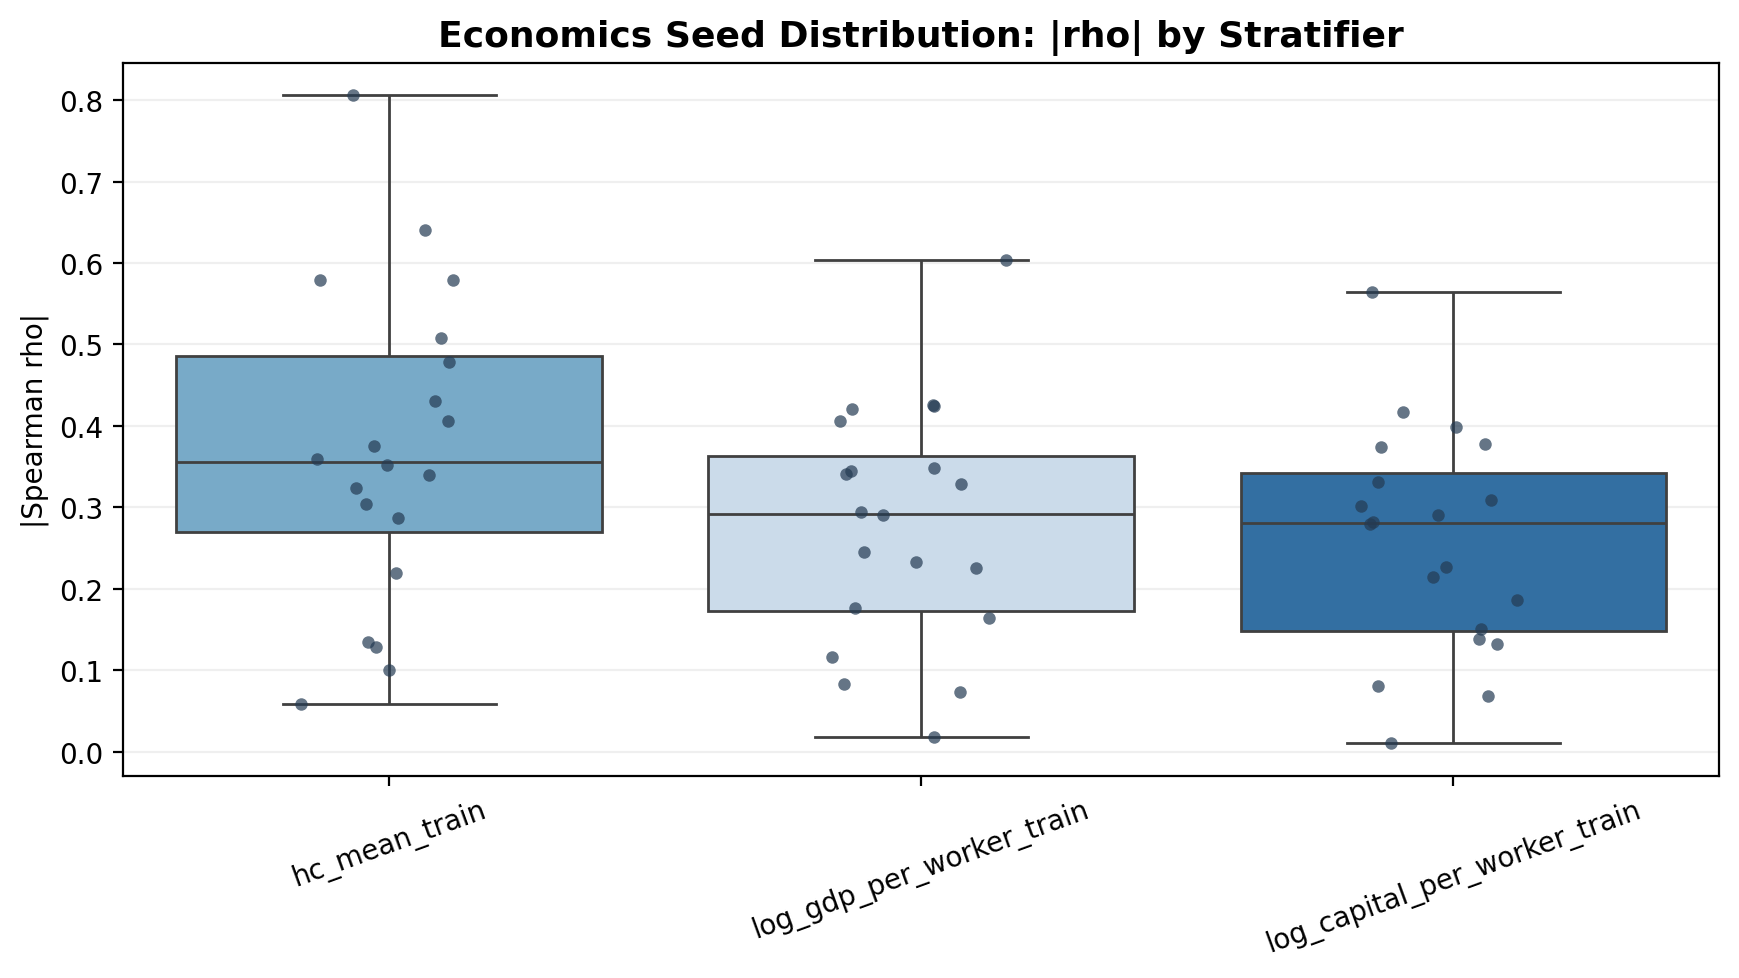

## economics_case_study.png

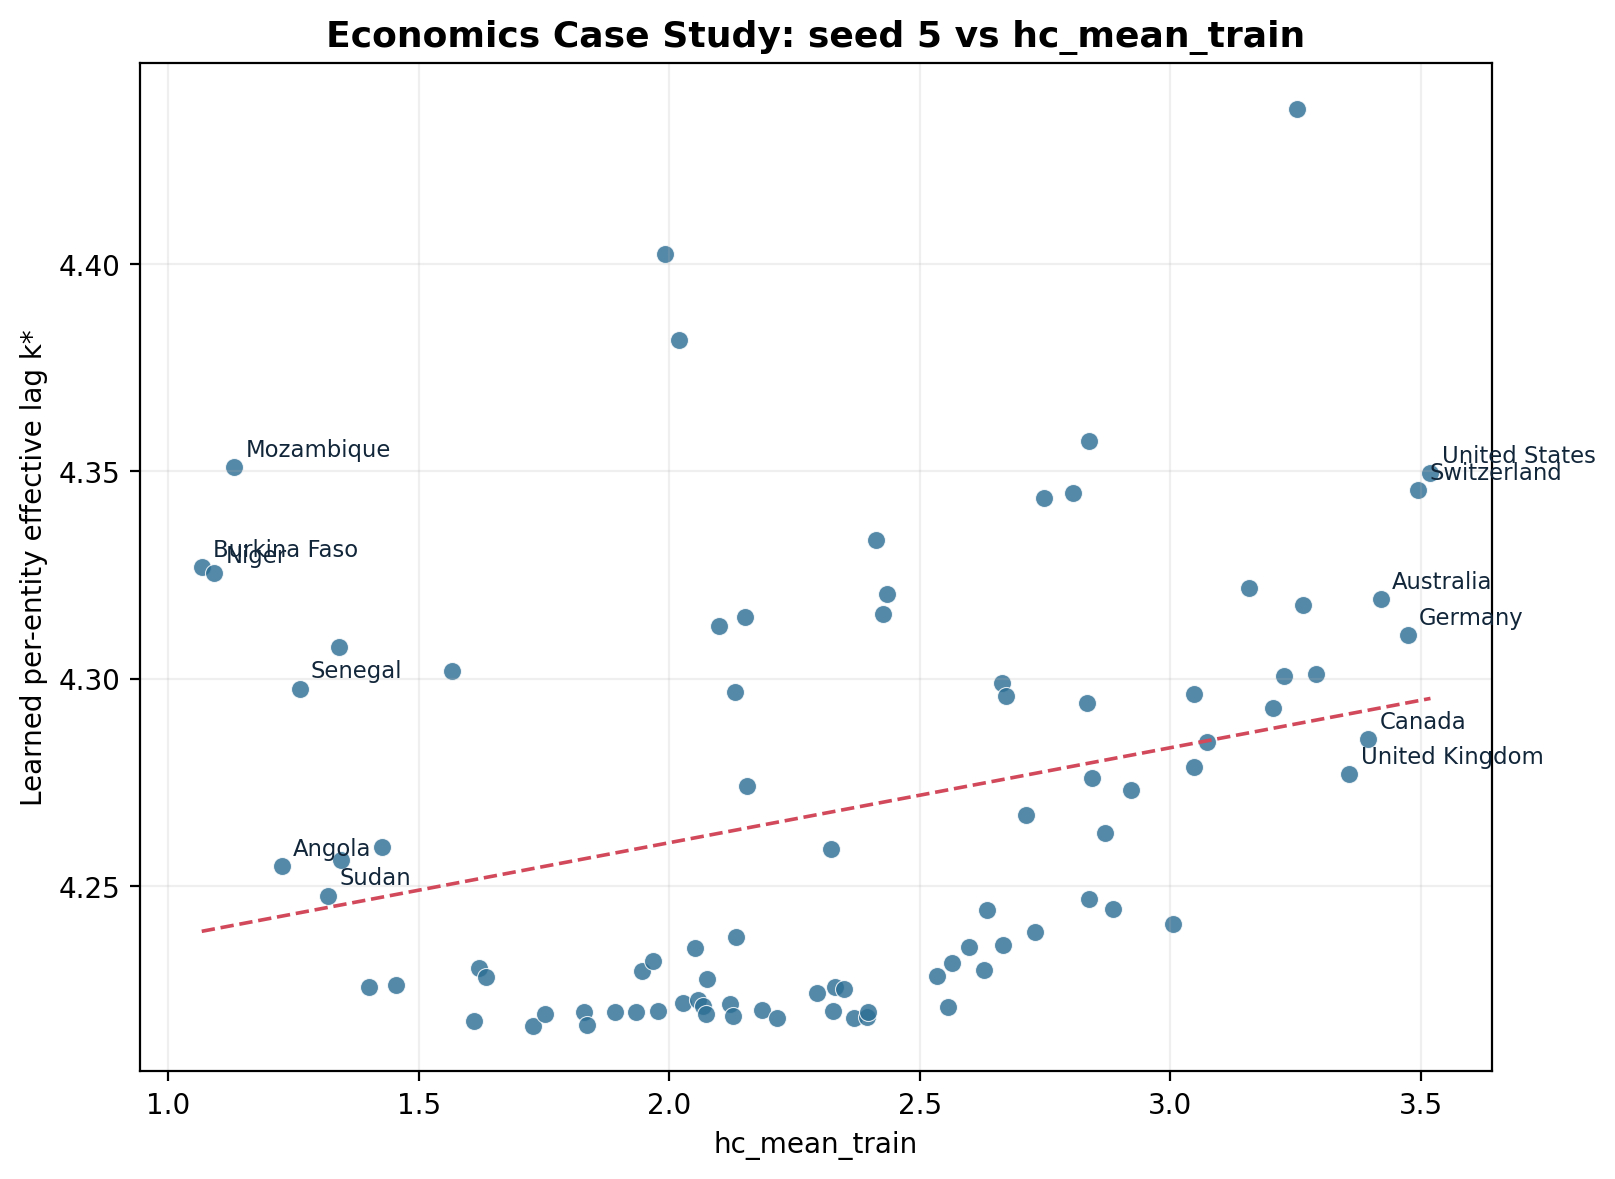

## energy_forecast_seed_distribution.png

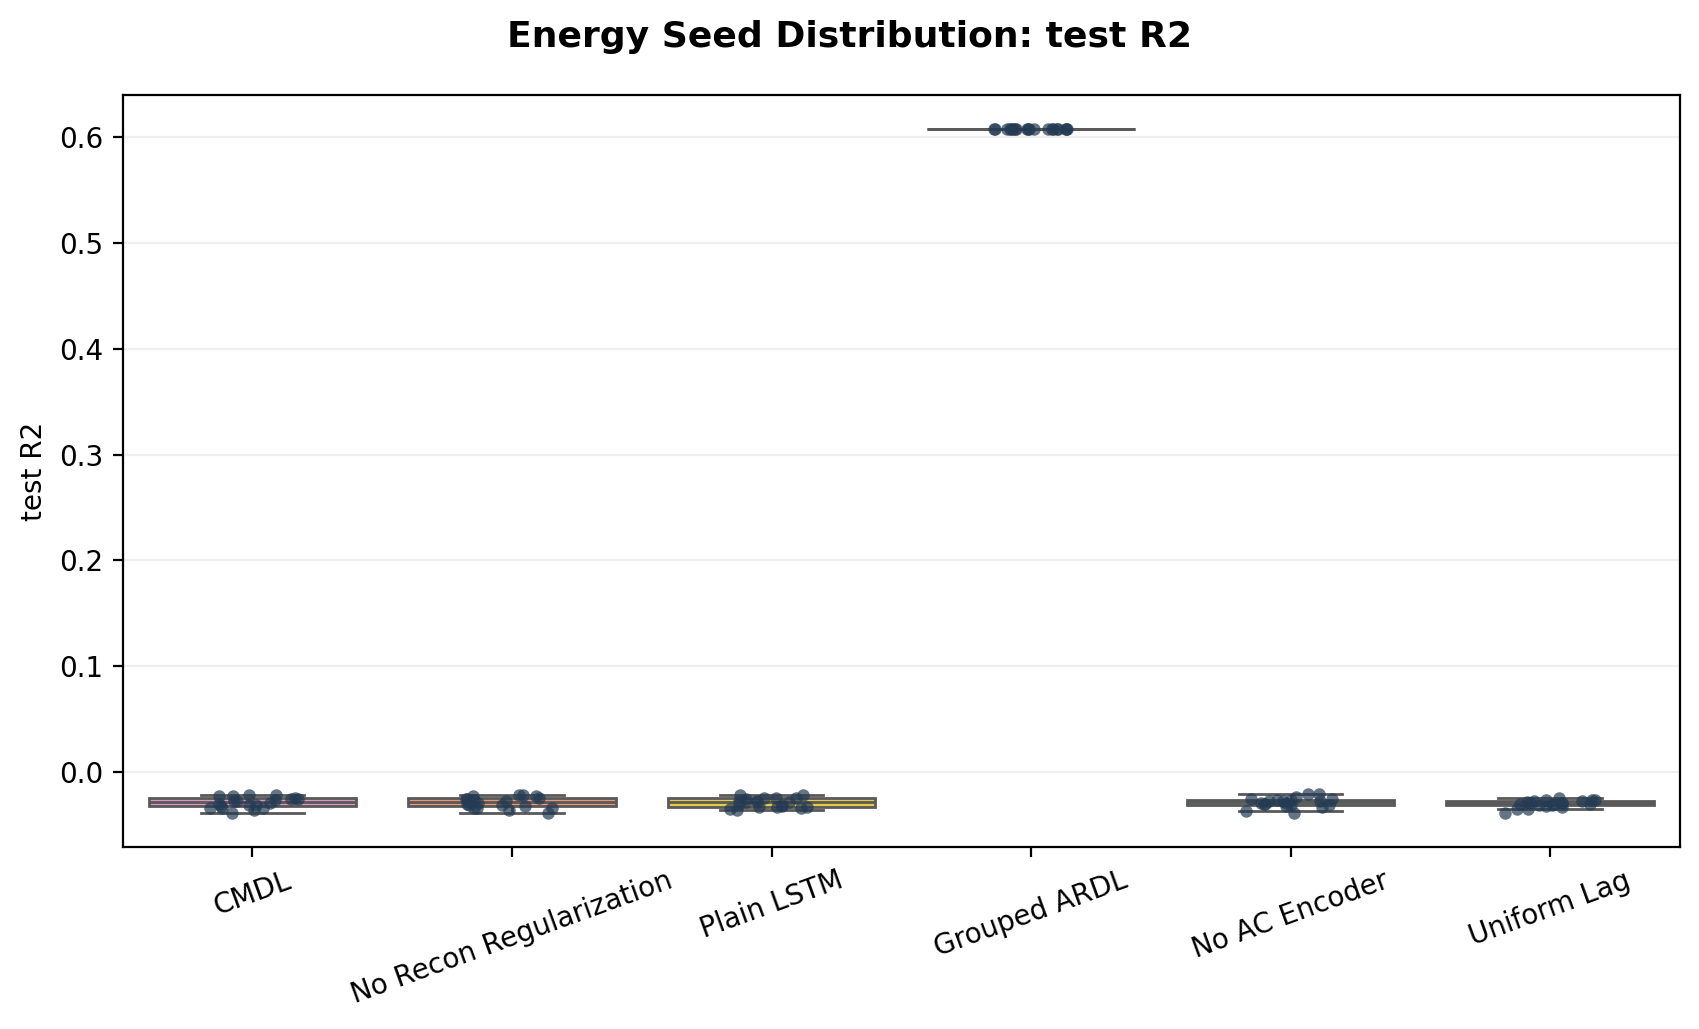

## energy_structured_mechanism_seed_distribution.png

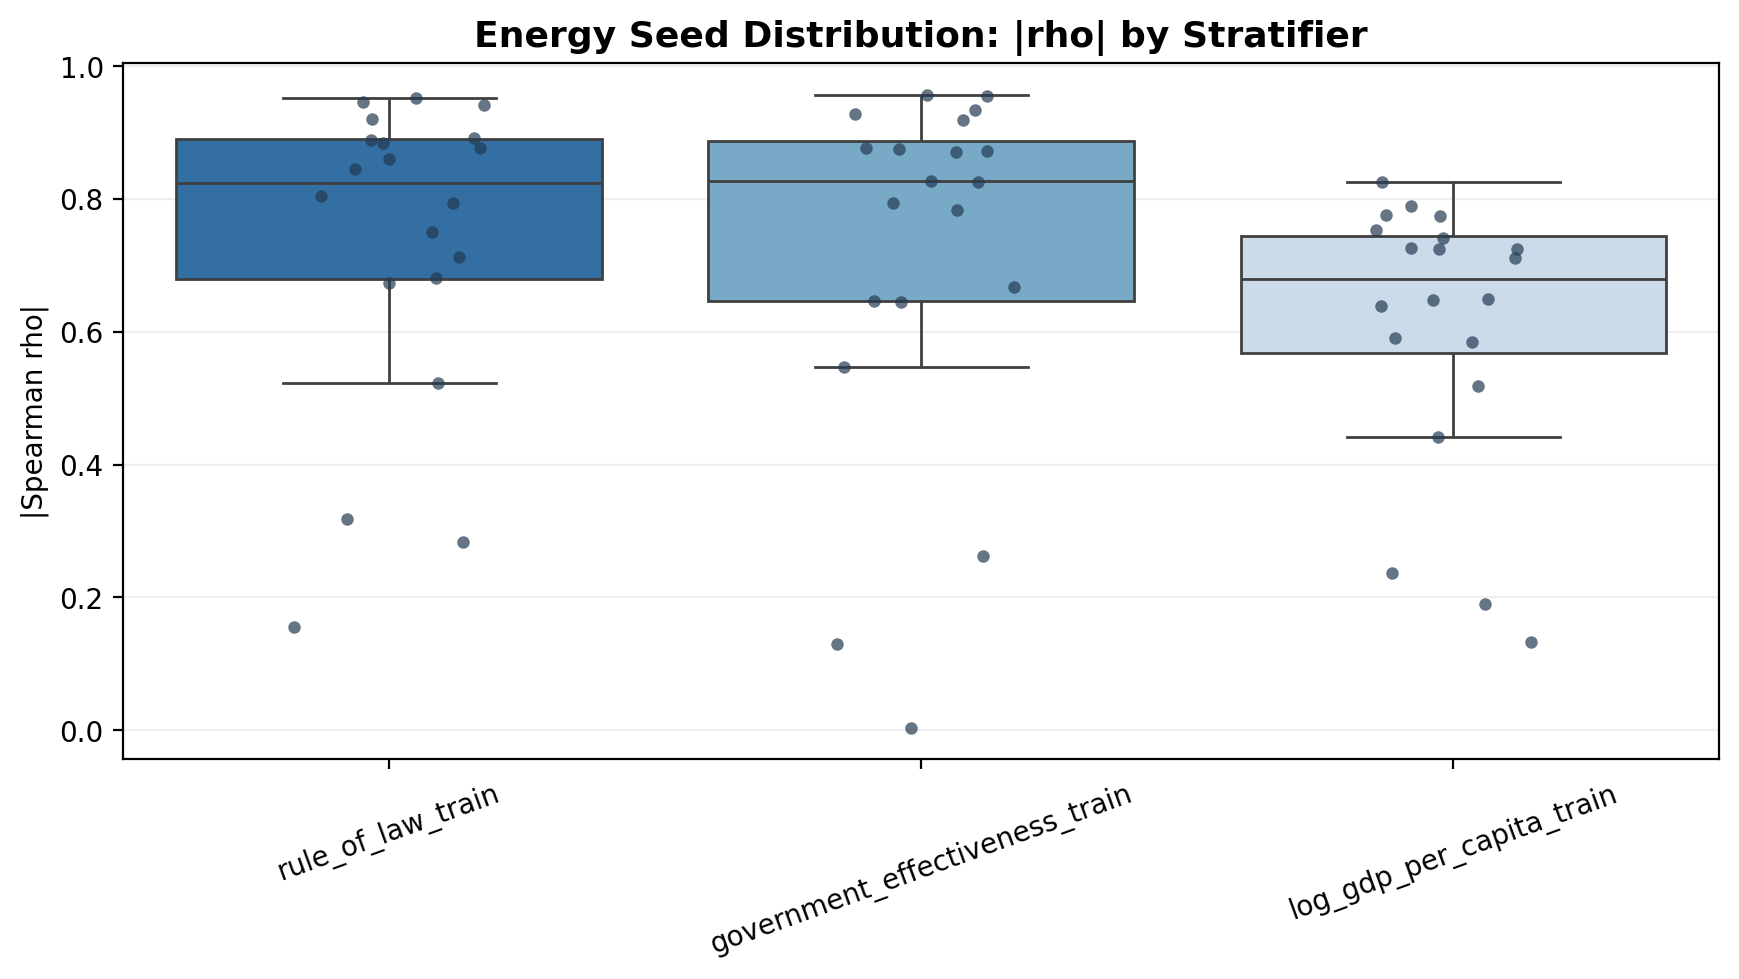

## energy_case_study.png

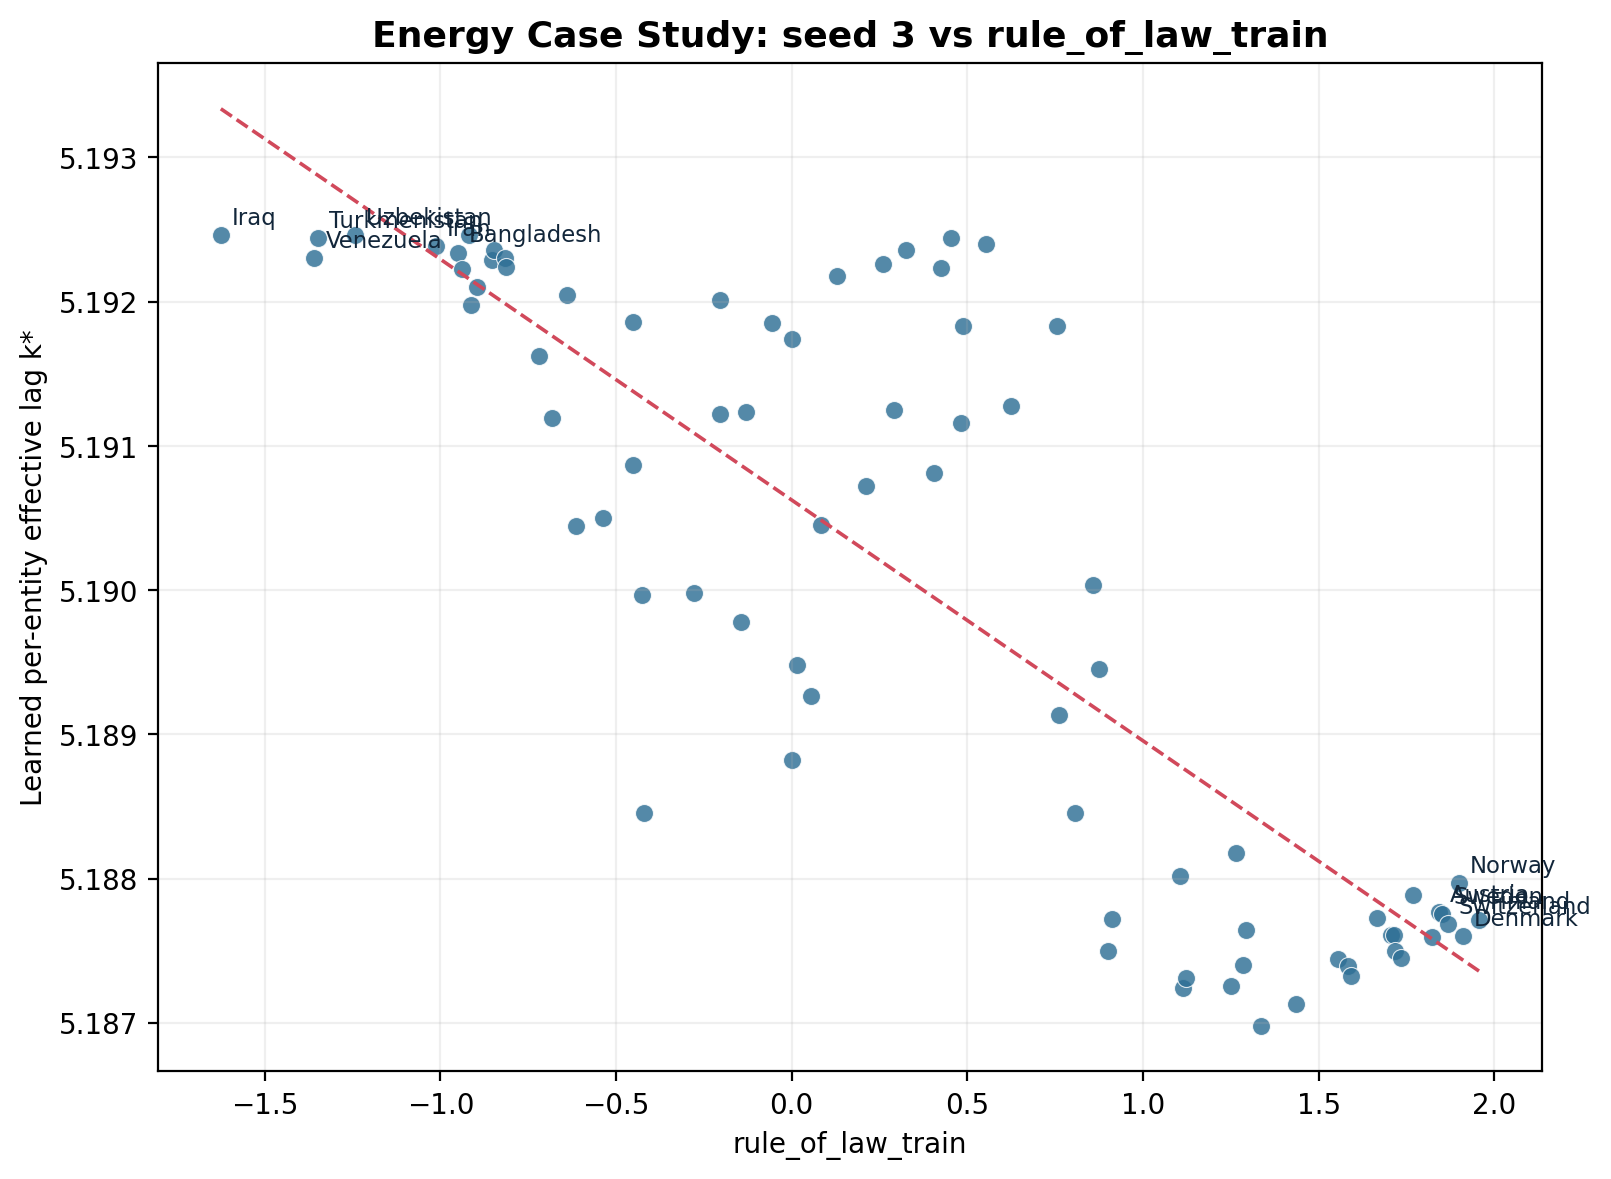

In [5]:
FIGURE_PREVIEW_ORDER = [
    'workflow_overview.png',
    'synthetic_kstar_mae_seed_distribution_linear.png',
    'synthetic_kstar_mae_seed_distribution_nonlinear.png',
    'economics_forecast_seed_distribution.png',
    'economics_structured_mechanism_seed_distribution.png',
    'economics_case_study.png',
    'energy_forecast_seed_distribution.png',
    'energy_structured_mechanism_seed_distribution.png',
    'energy_case_study.png',
]

for figure_name in FIGURE_PREVIEW_ORDER:
    if figure_name not in manifest['figures']:
        continue
    display(Markdown(f'## {figure_name}'))
    display(Image(filename=manifest['figures'][figure_name]))